In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/MarjorProjectDatasets-cropPrediction/Crop_recommendation_general.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load Data
df = pd.read_csv("/content/drive/MyDrive/MarjorProjectDatasets-cropPrediction/Crop_recommendation_general.csv")

# Features & Target
X = df.drop(columns=["label"])
y = df["label"]

# Encode label (crop names)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Model
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)  # Probability for all crops

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.9931818181818182

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00    

In [ ]:
sample = [[90, 42, 43, 20.87, 82.00, 6.50, 202.93]]
probs = model.predict_proba(sample)[0]

results = sorted(zip(le.classes_, probs), key=lambda x: x[1], reverse=True)

for crop, prob in results:
    print(f"{crop}: {prob*100:.6f}%")


rice: 99.000000%
jute: 1.000000%
apple: 0.000000%
banana: 0.000000%
blackgram: 0.000000%
chickpea: 0.000000%
coconut: 0.000000%
coffee: 0.000000%
cotton: 0.000000%
grapes: 0.000000%
kidneybeans: 0.000000%
lentil: 0.000000%
maize: 0.000000%
mango: 0.000000%
mothbeans: 0.000000%
mungbean: 0.000000%
muskmelon: 0.000000%
orange: 0.000000%
papaya: 0.000000%
pigeonpeas: 0.000000%
pomegranate: 0.000000%
watermelon: 0.000000%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


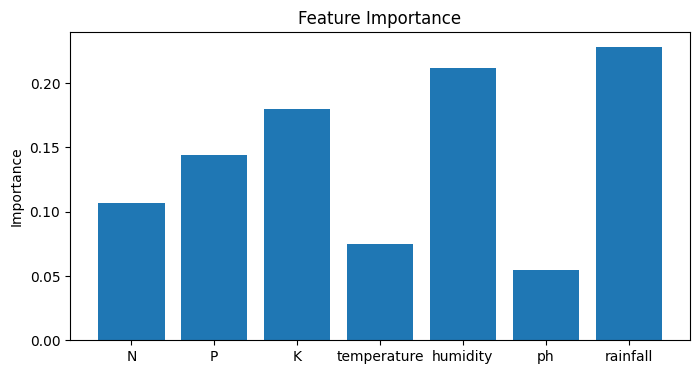

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.figure(figsize=(8,4))
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()


In [ ]:
misclassified = (y_test != y_pred).sum()
print("Misclassified samples:", misclassified)



Misclassified samples: 3


In [ ]:
sample = [[15, 10, 20, 12.5, 55.0, 6.8, 80.0]]  # Much lower rainfall & nitrogen
probs = model.predict_proba(sample)[0]

results = sorted(zip(le.classes_, probs), key=lambda x: x[1], reverse=True)

for crop, prob in results:
    print(f"{crop}: {prob*100:.6f}%")


mothbeans: 31.333333%
orange: 21.000000%
mango: 20.666667%
pigeonpeas: 10.333333%
maize: 3.666667%
pomegranate: 3.333333%
blackgram: 2.333333%
coffee: 2.333333%
lentil: 2.333333%
kidneybeans: 1.333333%
papaya: 0.666667%
chickpea: 0.333333%
grapes: 0.333333%
apple: 0.000000%
banana: 0.000000%
coconut: 0.000000%
cotton: 0.000000%
jute: 0.000000%
mungbean: 0.000000%
muskmelon: 0.000000%
rice: 0.000000%
watermelon: 0.000000%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

# Save model
with open("/content/drive/MyDrive/MarjorProjectDatasets-cropPrediction/Random_Forest_npk_recommendation.pkl", "wb") as f:
    pickle.dump(model, f)

# Save LabelEncoder too
with open("/content/drive/MyDrive/MarjorProjectDatasets-cropPrediction/Random_Forest_npk_recommendation.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Model and encoder saved successfully!")


✅ Model and encoder saved successfully!
